Import libraries 

In [1]:
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from sklearn.impute import SimpleImputer
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from ipywidgets import Dropdown, FloatSlider, IntSlider, interact
from sklearn.metrics import classification_report


PREPROCESSING

setting working directory and reading the file 

In [2]:
os.chdir(os.path.dirname(os.path.abspath("titanic_new.csv")))
df=pd.read_csv("titanic_new.csv")
print(df.head(5))
df.shape

   Passenger.Id  Survived  Pclass  \
0             1         0       3   
1             2         1       1   
2             3         1       3   
3             4         1       1   
4             5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket       Fare Cabin Embarked  
0      0         A/5 21171     '7.25'   NaN        S  
1      0          PC 17599  '71.2833'   C85        C  
2      0  STON/O2. 3101282    '7.925'   NaN        S  
3      0            113803     '53.1'  C123        S  
4      0            373450     '8.05'  

(891, 12)

searching for the columns with majority of null info and decided to drop "Cabin" beacuse it had a lot of missing values

In [3]:
print("Null values:\n", df.isnull().sum())
df.drop(columns=["Cabin"], inplace=True)

Null values:
 Passenger.Id      0
Survived          0
Pclass            0
Name              0
Sex               0
Age             177
SibSp             0
Parch             0
Ticket            0
Fare              0
Cabin           687
Embarked          2
dtype: int64


regarding "Age" and "Embarked" columns I decided to fill null values by using imputation.

In [4]:
temp1=SimpleImputer(missing_values=np.nan, strategy="mean")
df["Age"]=temp1.fit_transform(df[["Age"]])          # (n,1) -> (n,) beacuse it is numerical

tempp=SimpleImputer(missing_values=np.nan, strategy="most_frequent")
df["Embarked"]=tempp.fit_transform(df[["Embarked"]])[:, 0]      #[:,0] is essential to transform it into one column

df.isna().sum()

#simpleimputer always 2 dimentional dataframes!!

Passenger.Id    0
Survived        0
Pclass          0
Name            0
Sex             0
Age             0
SibSp           0
Parch           0
Ticket          0
Fare            0
Embarked        0
dtype: int64

In [5]:
print("Unique values:\n", df.nunique())
drop_cols=["Passenger.Id", "Name", "Ticket"]
df.drop(columns=drop_cols, inplace=True)

Unique values:
 Passenger.Id    891
Survived          5
Pclass            3
Name            891
Sex               8
Age              89
SibSp             7
Parch             7
Ticket          681
Fare            248
Embarked          4
dtype: int64


In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.754209,2.308642,29.699118,0.523008,0.381594
std,6.468695,0.836071,13.002015,1.102743,0.806057
min,-1.000000,1.000000,0.420000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000
50%,0.000000,3.000000,29.699118,0.000000,0.000000
75%,1.000000,3.000000,35.000000,1.000000,0.000000
max,112.000000,3.000000,80.000000,8.000000,6.000000


We can see that something is wrong with our data. Especially with "Survived" column.

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
23,111,1,male,28.0,0,0,'35.5',S
44,-1,3,female,19.0,0,0,'7.8792',Q
448,112,3,female,5.0,2,1,'19.2583',C
460,112,1,male,48.0,0,0,'26.55',S


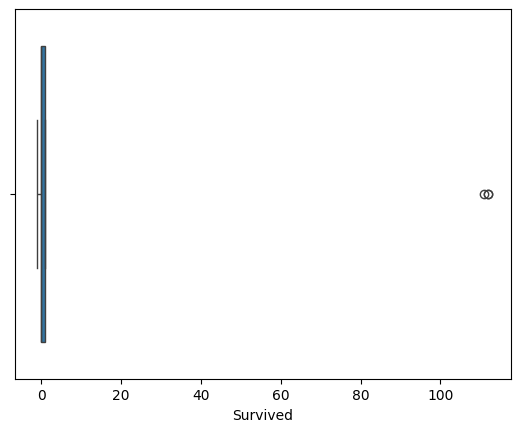

In [7]:
sns.boxplot(x=df['Survived'])
df[~df['Survived'].isin([0, 1])]

These are incorrect values which is shown on a boxplot and the dataframe.

In [8]:
for i in 23,44, 448,460:
    df.drop(index=i, inplace=True)

df[~df['Survived'].isin([0, 1])]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked


I decided to connect together "SibSp" and "Parch" columns to reduce dimentions of the data.

In [9]:
df["Relatives"] = df["SibSp"] + df["Parch"]
df.drop(columns="SibSp", inplace=True)
df.drop(columns="Parch", inplace=True)
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Relatives
0,0,3,male,22.0,'7.25',S,1
1,1,1,female,38.0,'71.2833',C,1
2,1,3,female,26.0,'7.925',S,0
3,1,1,female,35.0,'53.1',S,1
4,0,3,male,35.0,'8.05',S,0


In [10]:
df["Fare"].info()
df["Fare"]=df["Fare"].astype(str).str.replace("'" ,"", regex=False).astype(float)
df["Fare"].dtype

<class 'pandas.core.series.Series'>
Index: 887 entries, 0 to 890
Series name: Fare
Non-Null Count  Dtype 
--------------  ----- 
887 non-null    object
dtypes: object(1)
memory usage: 13.9+ KB


dtype('float64')

I changed type of "Fare" because it was object and I could not interpret this type of data.

In [11]:
df.info()
df["Sex"] = (df["Sex"] == "female").astype(int)
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 887 entries, 0 to 890
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Survived   887 non-null    int64  
 1   Pclass     887 non-null    int64  
 2   Sex        887 non-null    object 
 3   Age        887 non-null    float64
 4   Fare       887 non-null    float64
 5   Embarked   887 non-null    object 
 6   Relatives  887 non-null    int64  
dtypes: float64(2), int64(3), object(2)
memory usage: 55.4+ KB


,Survived,Pclass,Sex,Age,Fare,Embarked,Relatives
0,0,3,0,22.0,7.2500,S,1
1,1,1,1,38.0,71.2833,C,1
2,1,3,1,26.0,7.9250,S,0
3,1,1,1,35.0,53.1000,S,1
4,0,3,0,35.0,8.0500,S,0


Lastly, we have to do One Hot Encoding on "Embarked" values. I was not sure wheter i should include this column into my data. However, I decided that it is better to include it in the data set because it may contain useful information about passenger survival.

In [12]:
print(df["Embarked"].unique())
print(df[~df["Embarked"].isin(["S", "C", "Q"])])
for i in df.index:
    if df.loc[i, "Embarked"] not in ["S", "C", "Q"]:
        df.loc[i, "Embarked"] = "S"

ohe_embarked = pd.get_dummies(df["Embarked"], dtype=int)
df=pd.concat([df, ohe_embarked], axis=1)
df.drop(columns="Embarked", inplace=True)
df.head()

['S' 'C' 'Q' 's']
     Survived  Pclass  Sex   Age     Fare Embarked  Relatives
6           0       1    0  54.0  51.8625        s          0
7           0       3    0   2.0  21.0750        s          4
10          1       3    1   4.0  16.7000        s          2
12          0       3    0  20.0   8.0500        s          0
15          1       2    1  55.0  16.0000        s          0
21          1       2    0  34.0  13.0000        s          0
881         0       3    0  33.0   7.8958        s          0
882         0       3    1  22.0  10.5167        s          0
883         0       2    0  28.0  10.5000        s          0


,Survived,Pclass,Sex,Age,Fare,Relatives,C,Q,S
0,0,3,0,22.0,7.2500,1,0,0,1
1,1,1,1,38.0,71.2833,1,1,0,0
2,1,3,1,26.0,7.9250,0,0,0,1
3,1,1,1,35.0,53.1000,1,0,0,1
4,0,3,0,35.0,8.0500,0,0,0,1


Visualization

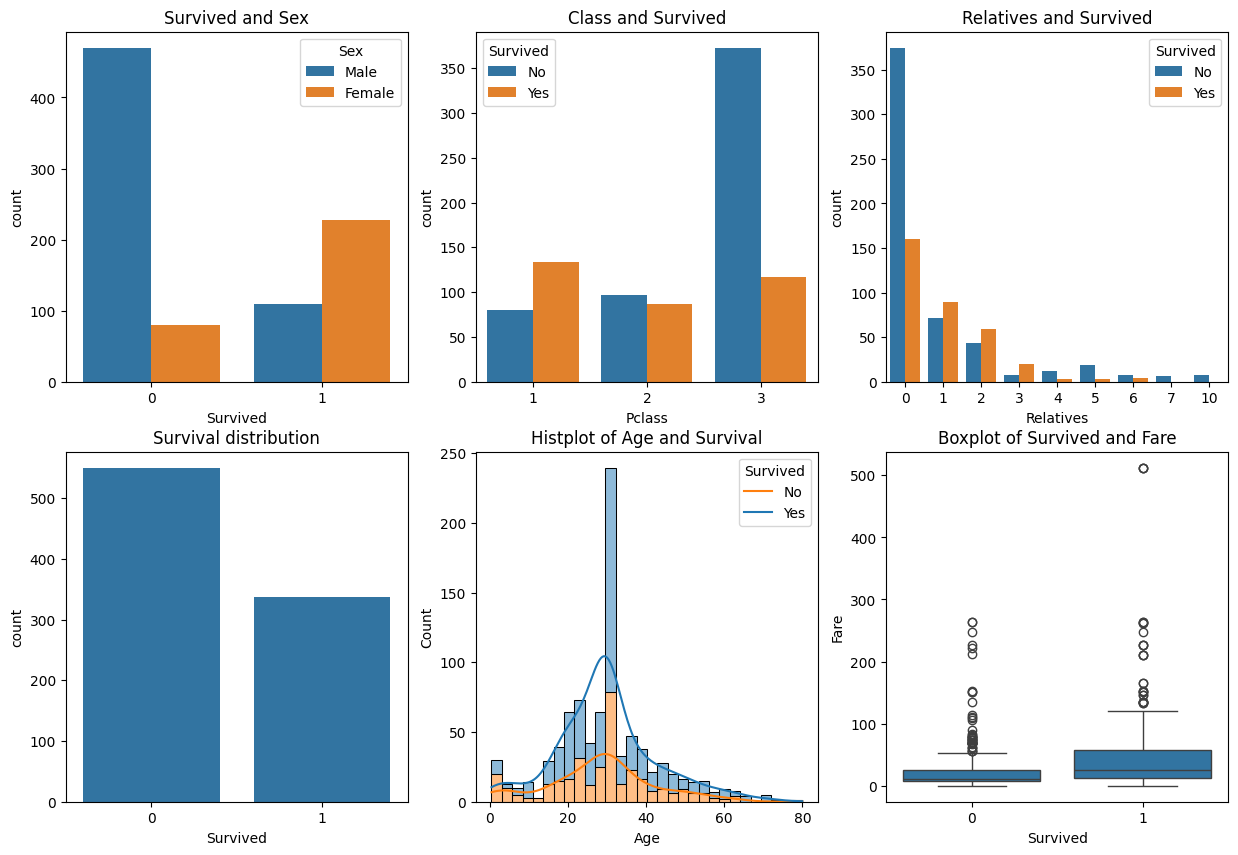

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.countplot(x="Survived", hue="Sex", data=df, ax=axes[0,0])
axes[0,0].legend(title="Sex", labels=["Male", "Female"])
axes[0,0].set_title("Survived and Sex")

sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[0,1])
axes[0,1].legend(title="Survived", labels=["No", "Yes"])
axes[0,1].set_title("Class and Survived")

sns.countplot(x="Relatives", hue='Survived', data=df, ax=axes[0,2])
axes[0,2].legend(title="Survived", labels=["No", "Yes"])
axes[0,2].set_title("Relatives and Survived")

sns.boxplot(x="Survived", y="Fare", data=df, ax=axes[1,2])
axes[1,2].set_title("Boxplot of Survived and Fare")

sns.countplot(data=df, x="Survived", ax=axes[1,0])
axes[1,0].set_title("Survival distribution")

sns.histplot(data=df, x="Age", hue="Survived", kde=True, multiple="stack", ax=axes[1,1])
axes[1,1].set_title("Histplot of Age and Survival")
axes[1,1].legend(title="Survived", labels=["No", "Yes"])



 As we can see from the plots, most of the female passengers survived. This indicates that gender played a strong role in survival chances. It cannot be denied that people without relatives on the board had higher survival rate than those who had siblings, parents or children travelling with them. The histogram shows that most survivors were younger adults. It is also evidient that those who had first or second class ticket were more likely yo be saved first. The boxplot of "survived and fare" indicates that passengers who paid higher fares tended to survive more often.

In [14]:
y=df["Survived"]
X=df.drop(columns="Survived")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(y_train.value_counts(normalize=True))


Survived
0    0.636107
1    0.363893
Name: proportion, dtype: float64


the class is imbalanced, so I will use RandomOverSampler 

In [15]:
over_sampler = RandomOverSampler( random_state=42 )
X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

In [16]:
acc_baseline = y_train.value_counts(normalize=True).max()
print("Accuracy Baseline:" , acc_baseline.round(2))

Accuracy Baseline: 0.64


In [17]:
model= RandomForestClassifier(n_estimators=70, max_depth=20, random_state=42)
model.fit(X_train_over, y_train_over)

,n_estimators,70
,criterion,'gini'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
acc_train = accuracy_score(y_train, model.predict(X_train))
acc_test = model.score(X_train_over, y_train_over)

print("Training Accuracy:", acc_train)
print("Test Accuracy:", acc_test)

Training Accuracy: 0.9830747531734838
Test Accuracy: 0.9855875831485588


I wanted to make sure my model works properly so i checked it with classification report.

In [19]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      0.85      0.84        98
           1       0.81      0.79      0.80        80

    accuracy                           0.82       178
   macro avg       0.82      0.82      0.82       178
weighted avg       0.82      0.82      0.82       178



In [20]:
def make_prediction(Pclass,Sex,Age,Fare,Relatives,Embarked):
    ports = {'C': [1,0,0], 'Q': [0,1,0], 'S': [0,0,1]}
    C, Q, S = ports[Embarked]

    data = {
        "Pclass": Pclass,
        "Sex": Sex,
        "Age": Age,
        "Fare": Fare,
        "Relatives" : Relatives,
        "C": C,
        "Q": Q,
        "S": S
    }

    df= pd.DataFrame(data, index=[0])
    
    prediction = model.predict(df)[0]
    probability = model.predict_proba(df)[0][1]

    if prediction == 1:
        print(f"Passenger would survive (probability: {probability:.2f})")
    else:
        print(f"Passenger would not survive (probability: {probability:.2f})")



interact(
    make_prediction, 
    Sex=Dropdown(options=[0, 1]),

    Pclass=Dropdown(options=[1, 2, 3], description="Class: "),

    Age=IntSlider(
        min=X_train["Age"].min(),
        max=X_train["Age"].max(),
        value=X_train["Age"].mean(),
        description="Age: "
    ),

    Fare=FloatSlider(
        min=X_train["Fare"].min(),
        max=X_train["Fare"].max(),
        value=X_train["Fare"].mean(),
        description="Fare: "
    ),

    Relatives=IntSlider(
        min=X_train["Relatives"].min(),
        max=X_train["Relatives"].max(),
        value=X_train["Relatives"].mean(),
        description="Relatives: "
    ),
    Embarked=Dropdown(options=['C', 'Q', 'S'],  description="Embarked: ")
)


interactive(children=(Dropdown(description='Class: ', options=(1, 2, 3), value=1), Dropdown(description='Sex',…

<function __main__.make_prediction(Pclass, Sex, Age, Fare, Relatives, Embarked)>